# LGBM V3 Tuning with Optuna (Bayesian Optimization)

Goal:
1. Tune **LightGBM on V3** to reduce SMAPE.
2. Keep MAE, RMSE, and |BIAS| controlled (guardrails).
3. Compare final test performance:
   - Tuned LGBM V3
   - Untuned LGBM V3
   - ChallengerXGBoost V3

In [13]:
from pathlib import Path
import warnings
import sys
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings('ignore')
RANDOM_SEED = 42

try:
    import optuna
except Exception:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'optuna'])
    import optuna

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

In [14]:
ROOT = Path('..')
DATA_DIR = ROOT / 'data' / 'processed' / 'LGBM_XGB_7_V3'
REPORTS_DIR = ROOT / 'artifacts' / 'reports'
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

train_df = pd.read_csv(DATA_DIR / 'train.csv')
val_df = pd.read_csv(DATA_DIR / 'val.csv')
test_df = pd.read_csv(DATA_DIR / 'test.csv')

for df in [train_df, val_df, test_df]:
    df['date'] = pd.to_datetime(df['date'], errors='coerce')

pd.DataFrame({
    'split': ['train', 'val', 'test'],
    'rows': [len(train_df), len(val_df), len(test_df)],
    'cols': [train_df.shape[1], val_df.shape[1], test_df.shape[1]],
    'null_cells': [int(train_df.isna().sum().sum()), int(val_df.isna().sum().sum()), int(test_df.isna().sum().sum())]
})

,split,rows,cols,null_cells
0,train,68976,34,0
1,val,14370,34,0
2,test,15807,34,0


In [15]:
# V3 feature schema (V2 features + snap_relevant)
target_col = 'aggregated_sales_7'
categorical_features = ['item_id']
numeric_features = [
    'is_month_end',
    'sales_lag_7',
    'sales_roll_mean_7',
    'aggregated_sell_price',
    'discount_depth',
    'sales_lag_1',
    'sales_lag_2',
    'sales_lag_4',
    'sales_roll_mean_2',
    'sales_roll_mean_4',
    'sales_roll_std_4',
    'price_lag_1',
    'price_change_bucket',
    'item_mean_train',
    'item_std_train',
    'item_cv_train',
    'weeks_since_first_seen',
    'snap_relevant',
]
event_features = [
    'event_christmas_7',
    'event_easter_7',
    'event_eid_al_fitr_7',
    'event_eid_al_adha_7',
    'event_fathers_day_7',
    'event_halloween_7',
    'event_mothers_day_7',
    'event_newyear_7',
    'event_orthodox_christmas_7',
    'event_orthodox_easter_7',
    'event_ramadan_starts_7',
    'event_thanksgiving_7',
    'event_valentines_day_7',
]

feature_cols = categorical_features + numeric_features + event_features
required_cols = feature_cols + [target_col, 'date']

missing_train = sorted(set(required_cols) - set(train_df.columns))
missing_val = sorted(set(required_cols) - set(val_df.columns))
missing_test = sorted(set(required_cols) - set(test_df.columns))
if missing_train or missing_val or missing_test:
    raise ValueError({
        'missing_train': missing_train,
        'missing_val': missing_val,
        'missing_test': missing_test,
    })

X_train = train_df[feature_cols].copy()
y_train = train_df[target_col].astype(float).copy()
X_val = val_df[feature_cols].copy()
y_val = val_df[target_col].astype(float).copy()
X_test = test_df[feature_cols].copy()
y_test = test_df[target_col].astype(float).copy()

X_pretest = pd.concat([train_df, val_df], ignore_index=True)[feature_cols].copy()
y_pretest = pd.concat([train_df, val_df], ignore_index=True)[target_col].astype(float).copy()

print('Feature count:', len(feature_cols))

Feature count: 32


In [16]:
def smape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return 100.0 * np.mean(2.0 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + eps))

def bias(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.mean(y_pred - y_true))

def evaluate_metrics(y_true, y_pred, model_name):
    return {
        'model': model_name,
        'MAE': float(mean_absolute_error(y_true, y_pred)),
        'RMSE': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'SMAPE': float(smape(y_true, y_pred)),
        'BIAS': float(bias(y_true, y_pred)),
    }

def make_preprocessor():
    return ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
            ('num', 'passthrough', numeric_features + event_features),
        ],
        remainder='drop'
    )

In [17]:
# Untuned baselines on validation (used for guardrails)
untuned_lgbm_val = Pipeline(steps=[
    ('prep', make_preprocessor()),
    ('model', LGBMRegressor(
        random_state=RANDOM_SEED,
        n_estimators=400,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.9,
        colsample_bytree=0.9,
    ))
])
untuned_lgbm_val.fit(X_train, y_train)
pred_untuned_val = untuned_lgbm_val.predict(X_val)
baseline_val = evaluate_metrics(y_val.values, pred_untuned_val, 'UntunedLightGBM_V3_val')

challenger_xgb_val = Pipeline(steps=[
    ('prep', make_preprocessor()),
    ('model', XGBRegressor(
        random_state=RANDOM_SEED,
        n_estimators=900,
        learning_rate=0.03,
        max_depth=8,
        min_child_weight=3,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.10,
        reg_lambda=1.00,
        objective='reg:squarederror',
        n_jobs=-1,
    ))
])
challenger_xgb_val.fit(X_train, y_train)
pred_xgb_val = challenger_xgb_val.predict(X_val)
challenger_val_metrics = evaluate_metrics(y_val.values, pred_xgb_val, 'ChallengerXGBoost_V3_val')

pd.DataFrame([baseline_val, challenger_val_metrics])

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012107 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6473
[LightGBM] [Info] Number of data points in the train set: 68976, number of used features: 1467
[LightGBM] [Info] Start training from score 14.243998


,model,MAE,RMSE,SMAPE,BIAS
0,UntunedLightGBM_V3_val,4.912294,10.955142,78.426203,-1.811620
1,ChallengerXGBoost_V3_val,5.010163,11.404428,78.098473,-1.593258


## Optuna Search Space
- `num_leaves`: 20-150
- `learning_rate`: 0.01-0.1
- `n_estimators`: 100-1000
- `min_child_samples`: 10-100
- `feature_fraction`: 0.5-1.0
- `bagging_fraction`: 0.5-1.0

Objective: Minimize SMAPE on validation while penalizing guardrail deterioration in MAE, RMSE, and |BIAS| compared to untuned LightGBM.

In [18]:
base_mae = baseline_val['MAE']
base_rmse = baseline_val['RMSE']
base_abs_bias = abs(baseline_val['BIAS'])

def objective(trial):
    params = {
        'random_state': RANDOM_SEED,
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample': trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('feature_fraction', 0.5, 1.0),
    }

    model = Pipeline(steps=[
        ('prep', make_preprocessor()),
        ('model', LGBMRegressor(**params)),
    ])
    model.fit(X_train, y_train)
    pred = model.predict(X_val)

    m = evaluate_metrics(y_val.values, pred, 'trial')
    s = m['SMAPE']
    mae = m['MAE']
    rmse = m['RMSE']
    abs_bias = abs(m['BIAS'])

    # Guardrail penalties (only when worse than untuned baseline)
    penalty_mae = max(0.0, (mae - base_mae) / max(base_mae, 1e-8))
    penalty_rmse = max(0.0, (rmse - base_rmse) / max(base_rmse, 1e-8))
    penalty_bias = max(0.0, (abs_bias - base_abs_bias) / max(base_abs_bias, 1e-8))

    objective_value = s + 15.0 * penalty_mae + 10.0 * penalty_rmse + 8.0 * penalty_bias

    trial.set_user_attr('SMAPE', s)
    trial.set_user_attr('MAE', mae)
    trial.set_user_attr('RMSE', rmse)
    trial.set_user_attr('BIAS', m['BIAS'])
    trial.set_user_attr('guardrail_penalty', objective_value - s)

    return objective_value

study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED))
study.optimize(objective, n_trials=60, show_progress_bar=False)

print('Best objective:', round(study.best_value, 6))
print('Best params:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

[I 2026-04-11 17:00:15,582] A new study created in memory with name: no-name-da57b7ef-ee3e-46be-8706-e5cf88b03dc0


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007168 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3599
[LightGBM] [Info] Number of data points in the train set: 68976, number of used features: 30
[LightGBM] [Info] Start training from score 14.243998


[I 2026-04-11 17:00:19,368] Trial 0 finished with value: 78.60966430847895 and parameters: {'num_leaves': 69, 'learning_rate': 0.08927180304353628, 'n_estimators': 759, 'min_child_samples': 64, 'bagging_fraction': 0.5780093202212182, 'feature_fraction': 0.5779972601681014}. Best is trial 0 with value: 78.60966430847895.


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012323 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3599
[LightGBM] [Info] Number of data points in the train set: 68976, number of used features: 30
[LightGBM] [Info] Start training from score 14.243998


[I 2026-04-11 17:00:21,390] Trial 1 finished with value: 83.81098197620132 and parameters: {'num_leaves': 27, 'learning_rate': 0.07348118405270448, 'n_estimators': 641, 'min_child_samples': 74, 'bagging_fraction': 0.5102922471479012, 'feature_fraction': 0.9849549260809971}. Best is trial 0 with value: 78.60966430847895.


...

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011303 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3599
[LightGBM] [Info] Number of data points in the train set: 68976, number of used features: 30
[LightGBM] [Info] Start training from score 14.243998


[I 2026-04-11 17:02:27,474] Trial 58 finished with value: 75.4068187125515 and parameters: {'num_leaves': 26, 'learning_rate': 0.01200354475108713, 'n_estimators': 465, 'min_child_samples': 57, 'bagging_fraction': 0.7448768514967331, 'feature_fraction': 0.8059421599853053}. Best is trial 53 with value: 73.5437381785977.


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.015435 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3599
[LightGBM] [Info] Number of data points in the train set: 68976, number of used features: 30
[LightGBM] [Info] Start training from score 14.243998


[I 2026-04-11 17:02:28,538] Trial 59 finished with value: 73.72329880818984 and parameters: {'num_leaves': 23, 'learning_rate': 0.010466491729815683, 'n_estimators': 271, 'min_child_samples': 79, 'bagging_fraction': 0.8382036311984281, 'feature_fraction': 0.7519556747409999}. Best is trial 53 with value: 73.5437381785977.


Best objective: 73.543738
Best params:
  num_leaves: 28
  learning_rate: 0.01123422644937414
  n_estimators: 257
  min_child_samples: 66
  bagging_fraction: 0.8284281988332782
  feature_fraction: 0.676121150135822


In [19]:
# Validation summary: untuned vs tuned vs challenger
best_params = study.best_params.copy()
tuned_lgbm_val = Pipeline(steps=[
    ('prep', make_preprocessor()),
    ('model', LGBMRegressor(
        random_state=RANDOM_SEED,
        num_leaves=int(best_params['num_leaves']),
        learning_rate=float(best_params['learning_rate']),
        n_estimators=int(best_params['n_estimators']),
        min_child_samples=int(best_params['min_child_samples']),
        subsample=float(best_params['bagging_fraction']),
        colsample_bytree=float(best_params['feature_fraction']),
    ))
])
tuned_lgbm_val.fit(X_train, y_train)
pred_tuned_val = tuned_lgbm_val.predict(X_val)
tuned_val_metrics = evaluate_metrics(y_val.values, pred_tuned_val, 'TunedLightGBM_V3_val')

val_summary = pd.DataFrame([baseline_val, tuned_val_metrics, challenger_val_metrics])
val_summary['BIAS_abs'] = val_summary['BIAS'].abs()
val_summary.sort_values(['SMAPE', 'MAE', 'RMSE', 'BIAS_abs'], ascending=[True, True, True, True]).reset_index(drop=True)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012663 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3599
[LightGBM] [Info] Number of data points in the train set: 68976, number of used features: 30
[LightGBM] [Info] Start training from score 14.243998


,model,MAE,RMSE,SMAPE,BIAS,BIAS_abs
0,TunedLightGBM_V3_val,4.921565,10.101015,73.515428,-0.238329,0.238329
1,ChallengerXGBoost_V3_val,5.010163,11.404428,78.098473,-1.593258,1.593258
2,UntunedLightGBM_V3_val,4.912294,10.955142,78.426203,-1.811620,1.811620


In [20]:
# Final test comparison on V3 (train+val -> test)
untuned_lgbm_test = Pipeline(steps=[
    ('prep', make_preprocessor()),
    ('model', LGBMRegressor(
        random_state=RANDOM_SEED,
        n_estimators=400,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.9,
        colsample_bytree=0.9,
    ))
])

tuned_lgbm_test = Pipeline(steps=[
    ('prep', make_preprocessor()),
    ('model', LGBMRegressor(
        random_state=RANDOM_SEED,
        num_leaves=int(best_params['num_leaves']),
        learning_rate=float(best_params['learning_rate']),
        n_estimators=int(best_params['n_estimators']),
        min_child_samples=int(best_params['min_child_samples']),
        subsample=float(best_params['bagging_fraction']),
        colsample_bytree=float(best_params['feature_fraction']),
    ))
])

challenger_xgb_test = Pipeline(steps=[
    ('prep', make_preprocessor()),
    ('model', XGBRegressor(
        random_state=RANDOM_SEED,
        n_estimators=900,
        learning_rate=0.03,
        max_depth=8,
        min_child_weight=3,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.10,
        reg_lambda=1.00,
        objective='reg:squarederror',
        n_jobs=-1,
    ))
])

models = {
    'UntunedLightGBM_V3': untuned_lgbm_test,
    'TunedLightGBM_V3': tuned_lgbm_test,
    'ChallengerXGBoost_V3': challenger_xgb_test,
}

test_rows = []
test_preds = {}
for name, mdl in models.items():
    mdl.fit(X_pretest, y_pretest)
    p = mdl.predict(X_test)
    test_preds[name] = p
    row = evaluate_metrics(y_test.values, p, name)
    test_rows.append(row)

test_metrics = pd.DataFrame(test_rows)
test_metrics['BIAS_abs'] = test_metrics['BIAS'].abs()
test_metrics = test_metrics.sort_values(['SMAPE', 'MAE', 'RMSE', 'BIAS_abs'], ascending=[True, True, True, True]).reset_index(drop=True)
test_metrics

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015695 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6510
[LightGBM] [Info] Number of data points in the train set: 83346, number of used features: 1468
[LightGBM] [Info] Start training from score 14.027932
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.014382 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3636
[LightGBM] [Info] Number of data points in the train set: 83346, number of used features: 31
[LightGBM] [Info] Start training from score 14.027932


,model,MAE,RMSE,SMAPE,BIAS,BIAS_abs
0,TunedLightGBM_V3,4.893690,9.507442,64.534448,0.284794,0.284794
1,ChallengerXGBoost_V3,4.830644,9.675082,64.658911,0.717612,0.717612
2,UntunedLightGBM_V3,4.800202,9.728443,65.111435,0.477117,0.477117


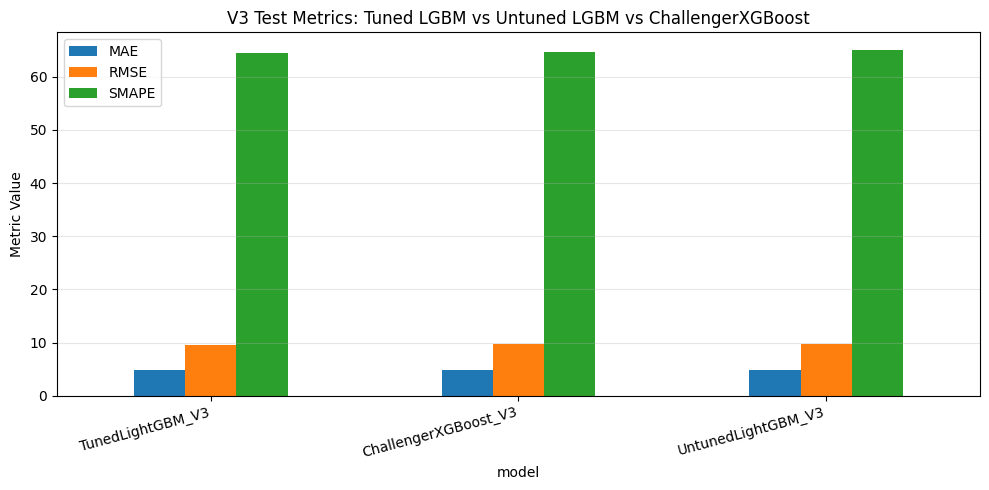

In [9]:
# Plot 1: Metrics comparison
plot_df = test_metrics[['model', 'MAE', 'RMSE', 'SMAPE']].set_index('model')
ax = plot_df.plot(kind='bar', figsize=(10, 5))
ax.set_title('V3 Test Metrics: Tuned LGBM vs Untuned LGBM vs ChallengerXGBoost')
ax.set_ylabel('Metric Value')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

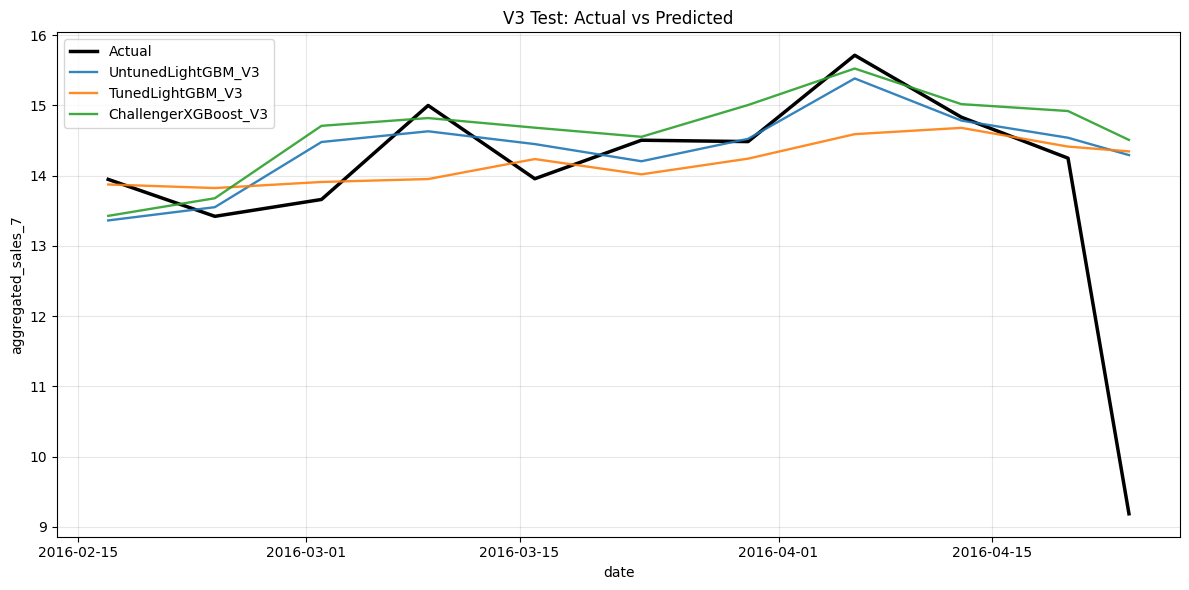

In [10]:
# Plot 2: Actual vs predicted (date-aggregated)
curve = test_df[['date', target_col]].copy().groupby('date', as_index=False)[target_col].mean()
curve = curve.rename(columns={target_col: 'Actual'})

for name, pred in test_preds.items():
    tmp = test_df[['date']].copy()
    tmp[name] = pred
    tmp = tmp.groupby('date', as_index=False)[name].mean()
    curve = curve.merge(tmp, on='date', how='left')

plt.figure(figsize=(12, 6))
plt.plot(curve['date'], curve['Actual'], color='black', linewidth=2.5, label='Actual')
for name in test_preds.keys():
    plt.plot(curve['date'], curve[name], linewidth=1.7, alpha=0.9, label=name)

plt.title('V3 Test: Actual vs Predicted')
plt.xlabel('date')
plt.ylabel('aggregated_sales_7')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

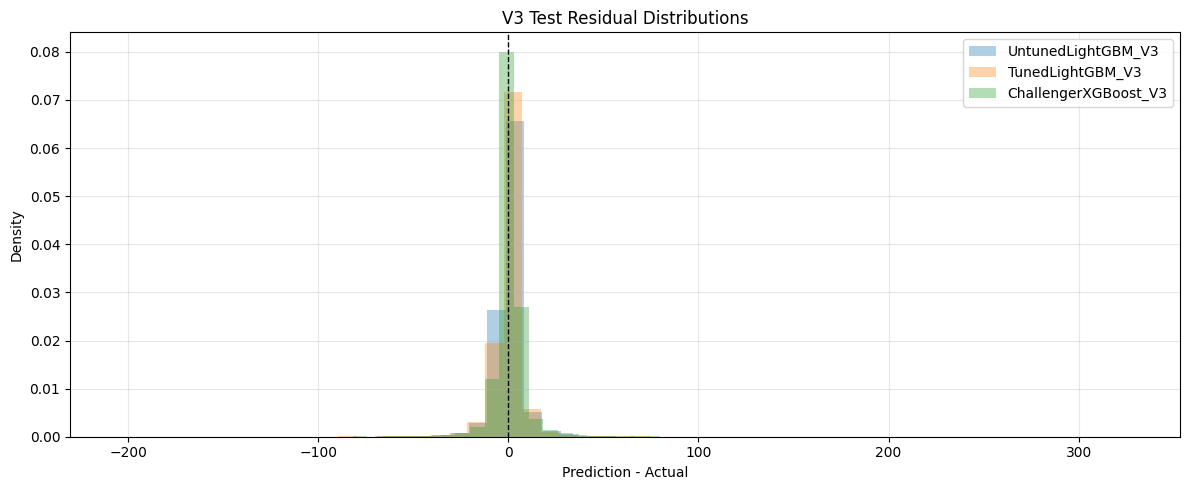

In [11]:
# Plot 3: Residual distributions
plt.figure(figsize=(12, 5))
for name, pred in test_preds.items():
    residual = pred - y_test.values
    plt.hist(residual, bins=50, alpha=0.35, density=True, label=name)

plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.title('V3 Test Residual Distributions')
plt.xlabel('Prediction - Actual')
plt.ylabel('Density')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
# Save outputs
test_metrics.to_csv(REPORTS_DIR / 'metrics_lgbm_v3_tuned_vs_untuned_vs_challenger.csv', index=False)
curve.to_csv(REPORTS_DIR / 'predictions_curve_lgbm_v3_tuned_vs_untuned_vs_challenger.csv', index=False)

print('Saved:', REPORTS_DIR / 'metrics_lgbm_v3_tuned_vs_untuned_vs_challenger.csv')
print('Saved:', REPORTS_DIR / 'predictions_curve_lgbm_v3_tuned_vs_untuned_vs_challenger.csv')

Saved: ..\artifacts\reports\metrics_lgbm_v3_tuned_vs_untuned_vs_challenger.csv
Saved: ..\artifacts\reports\predictions_curve_lgbm_v3_tuned_vs_untuned_vs_challenger.csv


In [22]:
from pathlib import Path
import json
import joblib

models_dir = ROOT / "artifacts" / "models"
models_dir.mkdir(parents=True, exist_ok=True)

model_path = models_dir / "tuned_lgbm_7_v3.joblib"
params_path = models_dir / "tuned_lgbm_7_v3_best_params.json"

joblib.dump(tuned_lgbm_test, model_path)
with open(params_path, "w", encoding="utf-8") as f:
    json.dump(best_params, f, indent=2)

print(f"Saved model: {model_path}")
print(f"Saved params: {params_path}")

Saved model: ..\artifacts\models\tuned_lgbm_7_v3.joblib
Saved params: ..\artifacts\models\tuned_lgbm_7_v3_best_params.json
